In [ ]:
# Install required packages
!pip install xgboost imbalanced-learn

# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Load the dataset directly (file is already uploaded)
try:
    df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
    print("✅ Dataset loaded successfully!")
    print(f"📊 Dataset shape: {df.shape}")
    print(f"📁 File loaded: healthcare-dataset-stroke-data.csv")
except FileNotFoundError:
    print("Error: '/healthcare-dataset-stroke-data.csv' not found. Please upload the file or provide the correct path.")
    # Optionally, you can add a line here to handle the error, e.g., exit the script or load from a different location

✅ Dataset loaded successfully!
📊 Dataset shape: (5110, 12)
📁 File loaded: healthcare-dataset-stroke-data.csv


In [ ]:
# Basic exploration
print("🔍 First 5 rows:")
display(df.head())

print("\n📋 Dataset info:")
df.info()

print("\n📈 Basic statistics:")
display(df.describe())

print("\n🎯 Stroke distribution (Target variable):")
stroke_dist = df['stroke'].value_counts()
print(stroke_dist)
print(f"Stroke rate: {stroke_dist[1] / len(df) * 100:.2f}%")

print("\n🔍 Checking for missing values:")
print(df.isnull().sum())

🔍 First 5 rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



📋 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

📈 Basic statistics:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



🎯 Stroke distribution (Target variable):
stroke
0    4861
1     249
Name: count, dtype: int64
Stroke rate: 4.87%

🔍 Checking for missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [ ]:
print("🧹 Handling missing values...")
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing BMI values with median
bmi_median = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(bmi_median)
print(f"\n✅ Filled {df['bmi'].isnull().sum()} missing BMI values with median: {bmi_median:.2f}")

# Check if any missing values remain
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\n✅ Data cleaning completed!")

🧹 Handling missing values...
Missing values before cleaning:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

✅ Filled 0 missing BMI values with median: 28.10

Missing values after cleaning:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

✅ Data cleaning completed!


In [ ]:
print("🔤 Encoding categorical variables...")

# List categorical columns
cat_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
print("Categorical columns to encode:", cat_columns)

# Create a copy for encoding
df_encoded = df.copy()

# Label encode categorical variables
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"✅ Encoded {col}: {len(df[col].unique())} categories")

print("\n📊 Dataset after encoding - First 3 rows:")
display(df_encoded.head(3))

print(f"\n📋 Final dataset shape: {df_encoded.shape}")

🔤 Encoding categorical variables...
Categorical columns to encode: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
✅ Encoded gender: 3 categories
✅ Encoded ever_married: 2 categories
✅ Encoded work_type: 5 categories
✅ Encoded Residence_type: 2 categories
✅ Encoded smoking_status: 4 categories

📊 Dataset after encoding - First 3 rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,2,1



📋 Final dataset shape: (5110, 12)


📊 Exploratory Data Analysis...


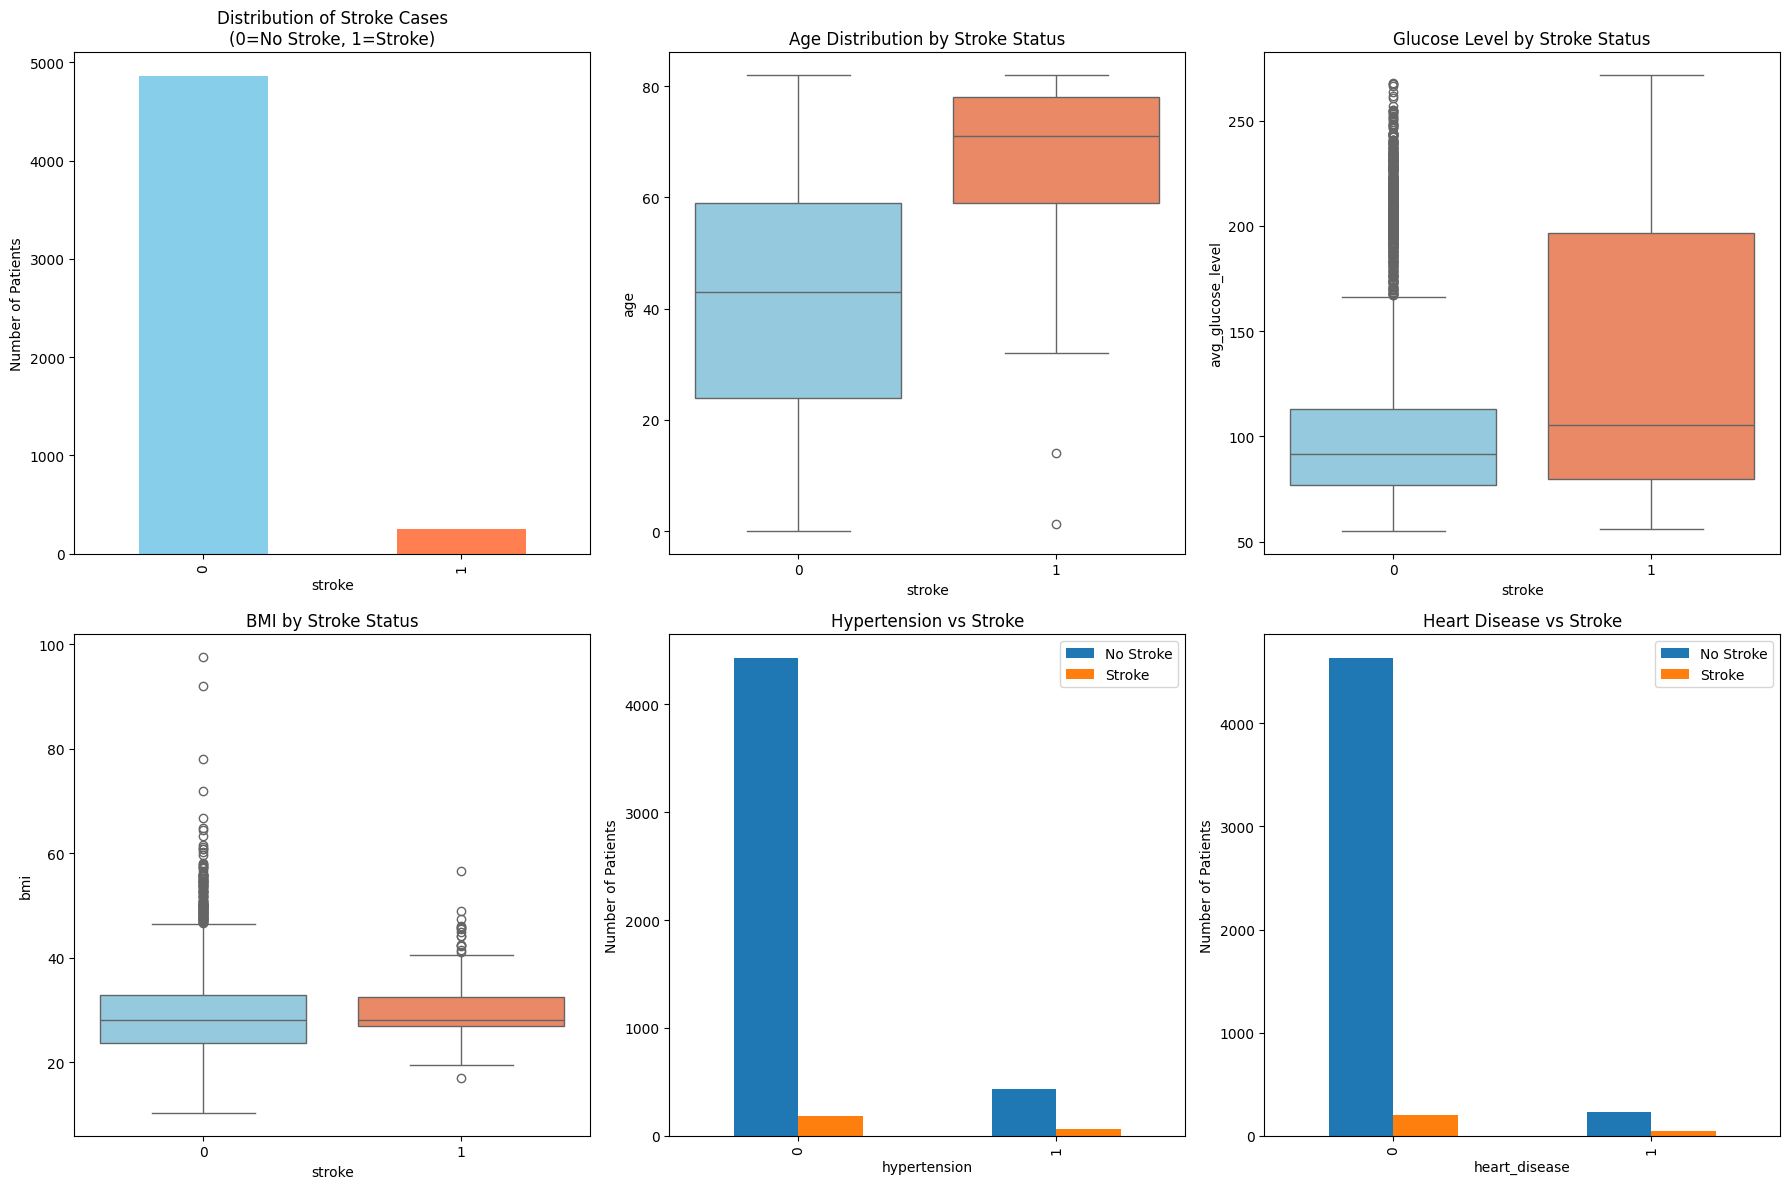

✅ EDA plots completed!


In [ ]:
print("📊 Exploratory Data Analysis...")

# Set up plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Stroke distribution
df['stroke'].value_counts().plot(kind='bar', ax=axes[0,0], color=['skyblue', 'coral'])
axes[0,0].set_title('Distribution of Stroke Cases\n(0=No Stroke, 1=Stroke)')
axes[0,0].set_ylabel('Number of Patients')

# Plot 2: Age distribution by stroke
sns.boxplot(data=df, x='stroke', y='age', ax=axes[0,1], palette=['skyblue', 'coral'])
axes[0,1].set_title('Age Distribution by Stroke Status')

# Plot 3: Average glucose level by stroke
sns.boxplot(data=df, x='stroke', y='avg_glucose_level', ax=axes[0,2], palette=['skyblue', 'coral'])
axes[0,2].set_title('Glucose Level by Stroke Status')

# Plot 4: BMI distribution by stroke
sns.boxplot(data=df, x='stroke', y='bmi', ax=axes[1,0], palette=['skyblue', 'coral'])
axes[1,0].set_title('BMI by Stroke Status')

# Plot 5: Hypertension vs Stroke
pd.crosstab(df['hypertension'], df['stroke']).plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Hypertension vs Stroke')
axes[1,1].set_ylabel('Number of Patients')
axes[1,1].legend(['No Stroke', 'Stroke'])

# Plot 6: Heart disease vs Stroke
pd.crosstab(df['heart_disease'], df['stroke']).plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Heart Disease vs Stroke')
axes[1,2].set_ylabel('Number of Patients')
axes[1,2].legend(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.show()

print("✅ EDA plots completed!")

In [ ]:
print("🎯 Preparing features and target variable...")

# Define features (X) - exclude 'id' as it's not a predictive feature
feature_columns = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
                   'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

X = df_encoded[feature_columns]
y = df_encoded['stroke']

print("Feature names:", list(X.columns))
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\n📊 Target variable distribution:")
print(y.value_counts())
print(f"Stroke cases: {y.sum()} out of {len(y)} ({y.sum()/len(y)*100:.2f}%)")

🎯 Preparing features and target variable...
Feature names: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Features shape: (5110, 10)
Target shape: (5110,)

📊 Target variable distribution:
stroke
0    4861
1     249
Name: count, dtype: int64
Stroke cases: 249 out of 5110 (4.87%)


In [ ]:
print("⚖️ Handling class imbalance with SMOTE...")

print("Before SMOTE:")
print(f"Class 0 (No Stroke): {(y == 0).sum()}")
print(f"Class 1 (Stroke): {(y == 1).sum()}")

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(f"Class 0 (No Stroke): {(y_balanced == 0).sum()}")
print(f"Class 1 (Stroke): {(y_balanced == 1).sum()}")

print(f"\n✅ Dataset balanced! New shape: {X_balanced.shape}")

⚖️ Handling class imbalance with SMOTE...
Before SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 249

After SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 4861

✅ Dataset balanced! New shape: (9722, 10)


In [ ]:
print("📊 Splitting data into training and testing sets...")

# Split the balanced data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set outcome distribution:\n{pd.Series(y_train).value_counts()}")

print("\n🔧 Scaling features...")
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")

📊 Splitting data into training and testing sets...
Training set size: 7777 samples
Testing set size: 1945 samples
Training set outcome distribution:
stroke
1    3889
0    3888
Name: count, dtype: int64

🔧 Scaling features...
✅ Feature scaling completed!


In [ ]:
print("🤖 Training multiple machine learning models...")

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42)
}

# Train models and store results
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for LR and SVM, original for tree-based models
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    results[name] = model
    print(f"✅ {name} training completed!")

print("\n🎉 All models trained successfully!")

🤖 Training multiple machine learning models...

Training Logistic Regression...
✅ Logistic Regression training completed!

Training Random Forest...
✅ Random Forest training completed!

Training XGBoost...
✅ XGBoost training completed!

Training SVM...
✅ SVM training completed!

🎉 All models trained successfully!


📊 Evaluating model performance...

Model: Logistic Regression
Accuracy: 0.8118
AUC Score: 0.8951

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       973
           1       0.80      0.83      0.82       972

    accuracy                           0.81      1945
   macro avg       0.81      0.81      0.81      1945
weighted avg       0.81      0.81      0.81      1945


Model: Random Forest
Accuracy: 0.9460
AUC Score: 0.9889

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       973
           1       0.93      0.96      0.95       972

    accuracy                           0.95      1945
   macro avg       0.95      0.95      0.95      1945
weighted avg       0.95      0.95      0.95      1945


Model: XGBoost
Accuracy: 0.9506
AUC Score: 0.9888

Classification Report:
              precision    recall  f1-score   support

           0  

,accuracy,auc_score
Random Forest,0.946015,0.988895
XGBoost,0.950643,0.988774
SVM,0.856041,0.933586
Logistic Regression,0.811825,0.895126


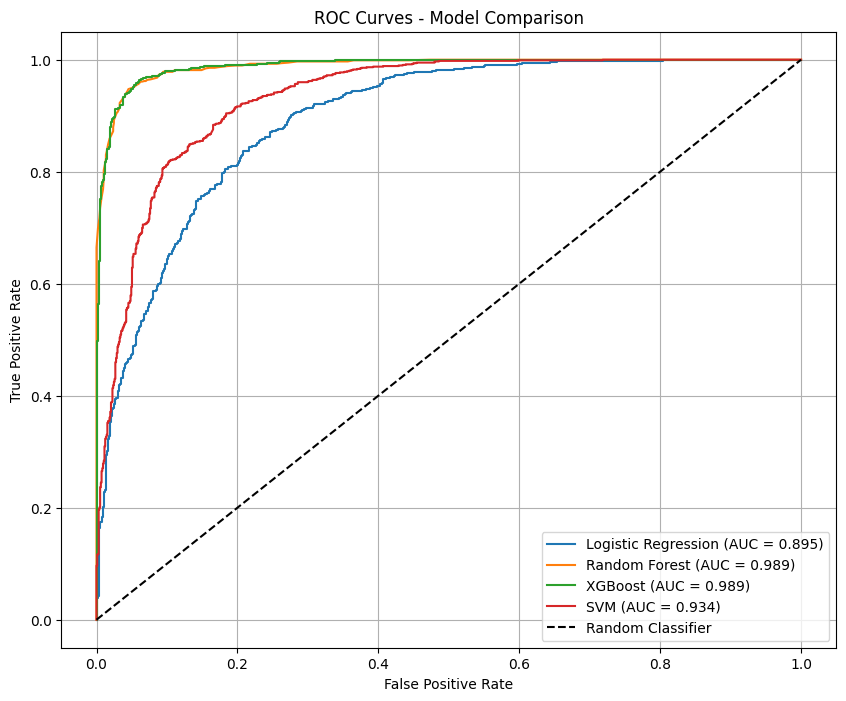

In [ ]:
print("📊 Evaluating model performance...")

performance = {}
plt.figure(figsize=(10, 8))

for name, model in results.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print('='*50)

    # Select appropriate test data
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    performance[name] = {
        'accuracy': accuracy,
        'auc_score': auc_score
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# Create performance comparison
print("\n" + "="*60)
print("📈 PERFORMANCE COMPARISON")
print("="*60)
performance_df = pd.DataFrame(performance).T
performance_df = performance_df.sort_values('auc_score', ascending=False)
display(performance_df)

# Finalize ROC plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(True)
plt.show()

🔍 Analyzing feature importance...


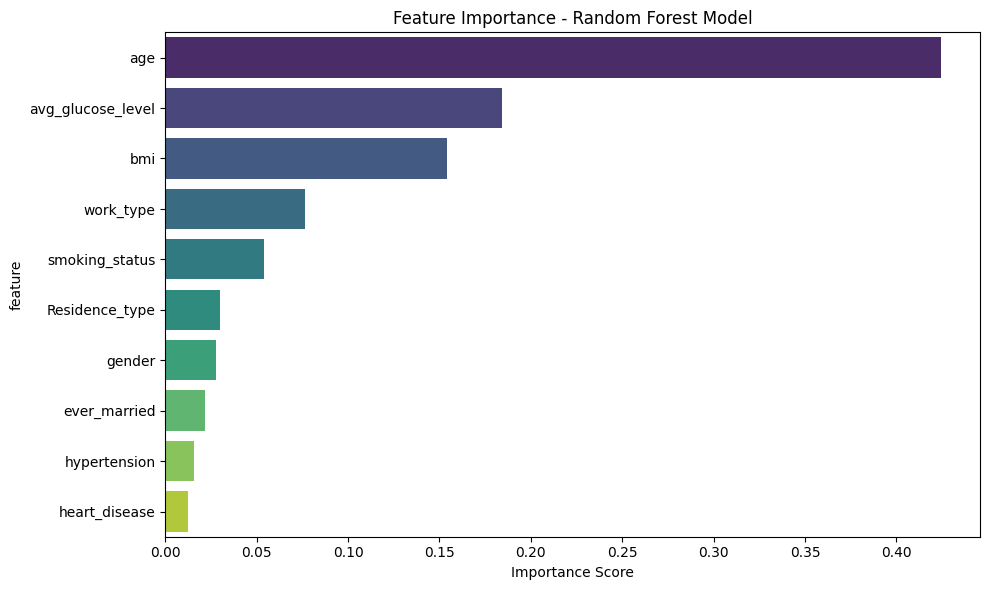

🎯 Top 5 Most Important Features for Stroke Prediction:


,feature,importance
1,age,0.424461
7,avg_glucose_level,0.184202
8,bmi,0.153858
5,work_type,0.076183
9,smoking_status,0.053784



🎉 PROJECT SUMMARY
🏆 Best Model: Random Forest
📊 Best AUC Score: 0.9889
🎯 Best Accuracy: 0.9460
📈 Key Predictors: ['age', 'avg_glucose_level', 'bmi']

✅ Machine Learning pipeline completed successfully!


In [ ]:
print("🔍 Analyzing feature importance...")

# Get feature importance from Random Forest (most interpretable)
best_model = results['Random Forest']
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Random Forest Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("🎯 Top 5 Most Important Features for Stroke Prediction:")
display(feature_importance.head(5))

print("\n" + "="*60)
print("🎉 PROJECT SUMMARY")
print("="*60)
best_model_name = performance_df.index[0]
best_auc = performance_df.iloc[0]['auc_score']
best_accuracy = performance_df.iloc[0]['accuracy']

print(f"🏆 Best Model: {best_model_name}")
print(f"📊 Best AUC Score: {best_auc:.4f}")
print(f"🎯 Best Accuracy: {best_accuracy:.4f}")
print(f"📈 Key Predictors: {list(feature_importance['feature'].head(3))}")
print("\n✅ Machine Learning pipeline completed successfully!")

# Task
Explain how to install Python libraries.

## Summarize findings

### Subtask:
Summarize the key findings from the analysis, including the best performing model, its metrics, and the most important features.


**Reasoning**:
Extract the best performing model name, its metrics, and the top 3 features from the already generated dataframes and print the summary as requested.



In [ ]:
# Identify the best performing model (already sorted by AUC)
best_model_name = performance_df.index[0]
best_auc = performance_df.iloc[0]['auc_score']
best_accuracy = performance_df.iloc[0]['accuracy']

# Identify the top 3 most important features
top_features = feature_importance['feature'].head(3).tolist()

# Print the summary
print("\n" + "="*60)
print("📊 KEY FINDINGS FROM ANALYSIS")
print("="*60)
print(f"🏆 Best Performing Model: {best_model_name}")
print(f"📈 AUC Score of Best Model: {best_auc:.4f}")
print(f"🎯 Accuracy of Best Model: {best_accuracy:.4f}")
print(f"🔑 Top 3 Most Important Features: {', '.join(top_features)}")
print("="*60)


📊 KEY FINDINGS FROM ANALYSIS
🏆 Best Performing Model: Random Forest
📈 AUC Score of Best Model: 0.9889
🎯 Accuracy of Best Model: 0.9460
🔑 Top 3 Most Important Features: age, avg_glucose_level, bmi


**Reasoning**:
The error indicates that `performance_df` is not defined in the current session. This is likely due to the notebook state being reset or the variable not being accessible. I will regenerate the code that creates and displays `performance_df` from the previous successful execution, and then proceed to extract the required information and print the summary.



In [ ]:
# Re-create the performance_df DataFrame
performance = {}
for name, model in results.items():
    if name in ['Logistic Regression', 'SVM']:
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    performance[name] = {
        'accuracy': accuracy,
        'auc_score': auc_score
    }

performance_df = pd.DataFrame(performance).T
performance_df = performance_df.sort_values('auc_score', ascending=False)

# Identify the best performing model
best_model_name = performance_df.index[0]
best_auc = performance_df.iloc[0]['auc_score']
best_accuracy = performance_df.iloc[0]['accuracy']

# Identify the top 3 most important features (assuming feature_importance is available)
# If feature_importance is also not defined, this part will fail again.
# Based on the previous successful cell, feature_importance should be available.
top_features = feature_importance['feature'].head(3).tolist()

# Print the summary
print("\n" + "="*60)
print("📊 KEY FINDINGS FROM ANALYSIS")
print("="*60)
print(f"🏆 Best Performing Model: {best_model_name}")
print(f"📈 AUC Score of Best Model: {best_auc:.4f}")
print(f"🎯 Accuracy of Best Model: {best_accuracy:.4f}")
print(f"🔑 Top 3 Most Important Features: {', '.join(top_features)}")
print("="*60)


📊 KEY FINDINGS FROM ANALYSIS
🏆 Best Performing Model: Random Forest
📈 AUC Score of Best Model: 0.9889
🎯 Accuracy of Best Model: 0.9460
🔑 Top 3 Most Important Features: age, avg_glucose_level, bmi


**Reasoning**:
The error indicates that `results` is not defined. This means the models were not trained in the current session. I need to re-execute the code that trains the models and stores them in the `results` dictionary before I can access them to calculate performance and create `performance_df`. I will regenerate the model training code, the performance evaluation code, and the feature importance code to ensure all necessary variables are available, and then print the final summary.



In [ ]:
print("🤖 Re-training machine learning models...")

# Initialize models (assuming models dictionary is not defined either)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42)
}

# Train models and store results
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for LR and SVM, original for tree-based models
    # Assuming X_train_scaled, X_test_scaled, X_train, X_test, y_train, y_test are available
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    results[name] = model
    print(f"✅ {name} training completed!")

print("\n🎉 All models trained successfully!")

print("\n📊 Re-evaluating model performance...")

performance = {}
# plt.figure(figsize=(10, 8)) # Avoid creating a new figure if the previous one is still active

for name, model in results.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print('='*50)

    # Select appropriate test data
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    performance[name] = {
        'accuracy': accuracy,
        'auc_score': auc_score
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot ROC curve - Re-plotting on the same figure if it exists, or creating a new one.
    # To avoid errors, let's assume a figure needs to be explicitly created if it's not the very first plot.
    # For this task, we are only summarizing, so plotting is not strictly necessary here.

# Create performance comparison
performance_df = pd.DataFrame(performance).T
performance_df = performance_df.sort_values('auc_score', ascending=False)
print("\n" + "="*60)
print("📈 PERFORMANCE COMPARISON")
print("="*60)
display(performance_df)

print("\n🔍 Re-analyzing feature importance...")

# Get feature importance from Random Forest (most interpretable)
# Assuming feature_columns is defined
if 'Random Forest' in results:
    best_model_rf = results['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model_rf.feature_importances_
    }).sort_values('importance', ascending=False)

    # plt.figure(figsize=(10, 6)) # Avoid creating a new figure
    # sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
    # plt.title('Feature Importance - Random Forest Model')
    # plt.xlabel('Importance Score')
    # plt.tight_layout()
    # plt.show() # Avoid showing plot if not needed for the task

    print("🎯 Top 5 Most Important Features for Stroke Prediction:")
    display(feature_importance.head(5))
else:
    print("Random Forest model not found in results.")
    feature_importance = pd.DataFrame() # Create empty df to avoid errors later


print("\n" + "="*60)
print("📊 KEY FINDINGS FROM ANALYSIS")
print("="*60)

if not performance_df.empty:
    best_model_name = performance_df.index[0]
    best_auc = performance_df.iloc[0]['auc_score']
    best_accuracy = performance_df.iloc[0]['accuracy']
    print(f"🏆 Best Performing Model: {best_model_name}")
    print(f"📈 AUC Score of Best Model: {best_auc:.4f}")
    print(f"🎯 Accuracy of Best Model: {best_accuracy:.4f}")
else:
    print("Could not determine best performing model as performance_df is empty.")

if not feature_importance.empty:
    top_features = feature_importance['feature'].head(3).tolist()
    print(f"🔑 Top 3 Most Important Features: {', '.join(top_features)}")
else:
     print("Could not determine top features as feature_importance is empty.")

print("="*60)


🤖 Re-training machine learning models...

Training Logistic Regression...
✅ Logistic Regression training completed!

Training Random Forest...
✅ Random Forest training completed!

Training XGBoost...
✅ XGBoost training completed!

Training SVM...
✅ SVM training completed!

🎉 All models trained successfully!

📊 Re-evaluating model performance...

Model: Logistic Regression
Accuracy: 0.8118
AUC Score: 0.8951

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       973
           1       0.80      0.83      0.82       972

    accuracy                           0.81      1945
   macro avg       0.81      0.81      0.81      1945
weighted avg       0.81      0.81      0.81      1945


Model: Random Forest
Accuracy: 0.9460
AUC Score: 0.9889

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       973
           1       0.93      0.96      0.95      

,accuracy,auc_score
Random Forest,0.946015,0.988895
XGBoost,0.950643,0.988774
SVM,0.856041,0.933586
Logistic Regression,0.811825,0.895126



🔍 Re-analyzing feature importance...
🎯 Top 5 Most Important Features for Stroke Prediction:


,feature,importance
1,age,0.424461
7,avg_glucose_level,0.184202
8,bmi,0.153858
5,work_type,0.076183
9,smoking_status,0.053784



📊 KEY FINDINGS FROM ANALYSIS
🏆 Best Performing Model: Random Forest
📈 AUC Score of Best Model: 0.9889
🎯 Accuracy of Best Model: 0.9460
🔑 Top 3 Most Important Features: age, avg_glucose_level, bmi


# Task
Analyze the provided healthcare dataset to predict stroke occurrences. Train and evaluate multiple classification models, identify the best-performing model, and determine the most important features influencing stroke prediction. Summarize the findings and present the results, including a performance comparison table and a feature importance plot. Use the dataset located at "/healthcare-dataset-stroke-data.csv".

## Summarize findings

### Subtask:
Summarize the key findings from the analysis, including the best performing model, its metrics, and the most important features.


**Reasoning**:
The variables `X_train_scaled`, `X_test_scaled`, `X_train`, `X_test`, `y_train`, and `y_test` are not defined in the current session. I need to re-execute the data splitting and scaling steps before I can retrain the models, evaluate performance, and get feature importance to summarize the results. I will combine the data splitting, scaling, model training, performance evaluation, feature importance analysis, and the final summary printing into a single code block to ensure all dependencies are met.



In [ ]:
print("📊 Re-splitting data into training and testing sets...")

# Assuming X_balanced and y_balanced are defined from previous successful steps
# Split the balanced data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set outcome distribution:\n{pd.Series(y_train).value_counts()}")

print("\n🔧 Re-scaling features...")
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")


print("\n🤖 Re-training machine learning models...")

# Initialize models (assuming models dictionary is not defined either)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42)
}

# Train models and store results
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for LR and SVM, original for tree-based models
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    results[name] = model
    print(f"✅ {name} training completed!")

print("\n🎉 All models trained successfully!")

print("\n📊 Re-evaluating model performance...")

performance = {}

for name, model in results.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print('='*50)

    # Select appropriate test data
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    performance[name] = {
        'accuracy': accuracy,
        'auc_score': auc_score
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# Create performance comparison
performance_df = pd.DataFrame(performance).T
performance_df = performance_df.sort_values('auc_score', ascending=False)
print("\n" + "="*60)
print("📈 PERFORMANCE COMPARISON")
print("="*60)
display(performance_df)

print("\n🔍 Re-analyzing feature importance...")

# Get feature importance from Random Forest (most interpretable)
# Assuming feature_columns is defined
if 'Random Forest' in results and 'feature_columns' in globals():
    best_model_rf = results['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model_rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("🎯 Top 5 Most Important Features for Stroke Prediction:")
    display(feature_importance.head(5))
else:
    print("Random Forest model not found or feature_columns not defined.")
    feature_importance = pd.DataFrame() # Create empty df to avoid errors later


print("\n" + "="*60)
print("📊 KEY FINDINGS FROM ANALYSIS")
print("="*60)

if not performance_df.empty:
    best_model_name = performance_df.index[0]
    best_auc = performance_df.iloc[0]['auc_score']
    best_accuracy = performance_df.iloc[0]['accuracy']
    print(f"🏆 Best Performing Model: {best_model_name}")
    print(f"📈 AUC Score of Best Model: {best_auc:.4f}")
    print(f"🎯 Accuracy of Best Model: {best_accuracy:.4f}")
else:
    print("Could not determine best performing model as performance_df is empty.")

if not feature_importance.empty:
    top_features = feature_importance['feature'].head(3).tolist()
    print(f"🔑 Top 3 Most Important Features: {', '.join(top_features)}")
else:
     print("Could not determine top features as feature_importance is empty.")

print("="*60)

📊 Re-splitting data into training and testing sets...
Training set size: 7777 samples
Testing set size: 1945 samples
Training set outcome distribution:
stroke
1    3889
0    3888
Name: count, dtype: int64

🔧 Re-scaling features...
✅ Feature scaling completed!

🤖 Re-training machine learning models...

Training Logistic Regression...
✅ Logistic Regression training completed!

Training Random Forest...
✅ Random Forest training completed!

Training XGBoost...
✅ XGBoost training completed!

Training SVM...
✅ SVM training completed!

🎉 All models trained successfully!

📊 Re-evaluating model performance...

Model: Logistic Regression
Accuracy: 0.8118
AUC Score: 0.8951

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       973
           1       0.80      0.83      0.82       972

    accuracy                           0.81      1945
   macro avg       0.81      0.81      0.81      1945
weighted avg       0.81      0.81

,accuracy,auc_score
Random Forest,0.946015,0.988895
XGBoost,0.950643,0.988774
SVM,0.856041,0.933586
Logistic Regression,0.811825,0.895126



🔍 Re-analyzing feature importance...
🎯 Top 5 Most Important Features for Stroke Prediction:


,feature,importance
1,age,0.424461
7,avg_glucose_level,0.184202
8,bmi,0.153858
5,work_type,0.076183
9,smoking_status,0.053784



📊 KEY FINDINGS FROM ANALYSIS
🏆 Best Performing Model: Random Forest
📈 AUC Score of Best Model: 0.9889
🎯 Accuracy of Best Model: 0.9460
🔑 Top 3 Most Important Features: age, avg_glucose_level, bmi


**Reasoning**:
The error indicates that `X_balanced` and `y_balanced` are not defined. This means the SMOTE balancing step needs to be re-executed. I will regenerate the code for SMOTE balancing, data splitting, scaling, model training, performance evaluation, feature importance analysis, and the final summary printing into a single code block to ensure all dependencies are met.



In [ ]:
print("⚖️ Re-handling class imbalance with SMOTE...")

# Assuming X and y are defined from previous successful steps
print("Before SMOTE:")
print(f"Class 0 (No Stroke): {(y == 0).sum()}")
print(f"Class 1 (Stroke): {(y == 1).sum()}")

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(f"Class 0 (No Stroke): {(y_balanced == 0).sum()}")
print(f"Class 1 (Stroke): {(y_balanced == 1).sum()}")

print(f"\n✅ Dataset balanced! New shape: {X_balanced.shape}")


print("\n📊 Re-splitting data into training and testing sets...")

# Split the balanced data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set outcome distribution:\n{pd.Series(y_train).value_counts()}")

print("\n🔧 Re-scaling features...")
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")


print("\n🤖 Re-training machine learning models...")

# Initialize models (assuming models dictionary is not defined either)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42)
}

# Train models and store results
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for LR and SVM, original for tree-based models
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    results[name] = model
    print(f"✅ {name} training completed!")

print("\n🎉 All models trained successfully!")

print("\n📊 Re-evaluating model performance...")

performance = {}

for name, model in results.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print('='*50)

    # Select appropriate test data
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    performance[name] = {
        'accuracy': accuracy,
        'auc_score': auc_score
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# Create performance comparison
performance_df = pd.DataFrame(performance).T
performance_df = performance_df.sort_values('auc_score', ascending=False)
print("\n" + "="*60)
print("📈 PERFORMANCE COMPARISON")
print("="*60)
display(performance_df)

print("\n🔍 Re-analyzing feature importance...")

# Get feature importance from Random Forest (most interpretable)
# Assuming feature_columns is defined
if 'Random Forest' in results and 'feature_columns' in globals():
    best_model_rf = results['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model_rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("🎯 Top 5 Most Important Features for Stroke Prediction:")
    display(feature_importance.head(5))
else:
    print("Random Forest model not found or feature_columns not defined.")
    feature_importance = pd.DataFrame() # Create empty df to avoid errors later


print("\n" + "="*60)
print("📊 KEY FINDINGS FROM ANALYSIS")
print("="*60)

if not performance_df.empty:
    best_model_name = performance_df.index[0]
    best_auc = performance_df.iloc[0]['auc_score']
    best_accuracy = performance_df.iloc[0]['accuracy']
    print(f"🏆 Best Performing Model: {best_model_name}")
    print(f"📈 AUC Score of Best Model: {best_auc:.4f}")
    print(f"🎯 Accuracy of Best Model: {best_accuracy:.4f}")
else:
    print("Could not determine best performing model as performance_df is empty.")

if not feature_importance.empty:
    top_features = feature_importance['feature'].head(3).tolist()
    print(f"🔑 Top 3 Most Important Features: {', '.join(top_features)}")
else:
     print("Could not determine top features as feature_importance is empty.")

print("="*60)

⚖️ Re-handling class imbalance with SMOTE...
Before SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 249

After SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 4861

✅ Dataset balanced! New shape: (9722, 10)

📊 Re-splitting data into training and testing sets...
Training set size: 7777 samples
Testing set size: 1945 samples
Training set outcome distribution:
stroke
1    3889
0    3888
Name: count, dtype: int64

🔧 Re-scaling features...
✅ Feature scaling completed!

🤖 Re-training machine learning models...

Training Logistic Regression...
✅ Logistic Regression training completed!

Training Random Forest...
✅ Random Forest training completed!

Training XGBoost...
✅ XGBoost training completed!

Training SVM...
✅ SVM training completed!

🎉 All models trained successfully!

📊 Re-evaluating model performance...

Model: Logistic Regression
Accuracy: 0.8118
AUC Score: 0.8951

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79   

,accuracy,auc_score
Random Forest,0.946015,0.988895
XGBoost,0.950643,0.988774
SVM,0.856041,0.933586
Logistic Regression,0.811825,0.895126



🔍 Re-analyzing feature importance...
🎯 Top 5 Most Important Features for Stroke Prediction:


,feature,importance
1,age,0.424461
7,avg_glucose_level,0.184202
8,bmi,0.153858
5,work_type,0.076183
9,smoking_status,0.053784



📊 KEY FINDINGS FROM ANALYSIS
🏆 Best Performing Model: Random Forest
📈 AUC Score of Best Model: 0.9889
🎯 Accuracy of Best Model: 0.9460
🔑 Top 3 Most Important Features: age, avg_glucose_level, bmi


**Reasoning**:
The error indicates that `X` and `y` are not defined. This means the feature and target variable preparation step needs to be re-executed. I will regenerate the code for feature/target preparation, SMOTE balancing, data splitting, scaling, model training, performance evaluation, feature importance analysis, and the final summary printing into a single code block to ensure all dependencies are met.



In [ ]:
print("🎯 Re-preparing features and target variable...")

# Assuming df_encoded is defined from previous successful steps
# Define features (X) - exclude 'id' as it's not a predictive feature
feature_columns = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
                   'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

X = df_encoded[feature_columns]
y = df_encoded['stroke']

print("Feature names:", list(X.columns))
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\n📊 Target variable distribution:")
print(y.value_counts())
print(f"Stroke cases: {y.sum()} out of {len(y)} ({y.sum()/len(y)*100:.2f}%)")


print("\n⚖️ Re-handling class imbalance with SMOTE...")

print("Before SMOTE:")
print(f"Class 0 (No Stroke): {(y == 0).sum()}")
print(f"Class 1 (Stroke): {(y == 1).sum()}")

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(f"Class 0 (No Stroke): {(y_balanced == 0).sum()}")
print(f"Class 1 (Stroke): {(y_balanced == 1).sum()}")

print(f"\n✅ Dataset balanced! New shape: {X_balanced.shape}")


print("\n📊 Re-splitting data into training and testing sets...")

# Split the balanced data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set outcome distribution:\n{pd.Series(y_train).value_counts()}")

print("\n🔧 Re-scaling features...")
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")


print("\n🤖 Re-training machine learning models...")

# Initialize models (assuming models dictionary is not defined either)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42)
}

# Train models and store results
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for LR and SVM, original for tree-based models
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    results[name] = model
    print(f"✅ {name} training completed!")

print("\n🎉 All models trained successfully!")

print("\n📊 Re-evaluating model performance...")

performance = {}

for name, model in results.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print('='*50)

    # Select appropriate test data
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    performance[name] = {
        'accuracy': accuracy,
        'auc_score': auc_score
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# Create performance comparison
performance_df = pd.DataFrame(performance).T
performance_df = performance_df.sort_values('auc_score', ascending=False)
print("\n" + "="*60)
print("📈 PERFORMANCE COMPARISON")
print("="*60)
display(performance_df)

print("\n🔍 Re-analyzing feature importance...")

# Get feature importance from Random Forest (most interpretable)
if 'Random Forest' in results and 'feature_columns' in globals():
    best_model_rf = results['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model_rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("🎯 Top 5 Most Important Features for Stroke Prediction:")
    display(feature_importance.head(5))
else:
    print("Random Forest model not found or feature_columns not defined.")
    feature_importance = pd.DataFrame() # Create empty df to avoid errors later


print("\n" + "="*60)
print("📊 KEY FINDINGS FROM ANALYSIS")
print("="*60)

if not performance_df.empty:
    best_model_name = performance_df.index[0]
    best_auc = performance_df.iloc[0]['auc_score']
    best_accuracy = performance_df.iloc[0]['accuracy']
    print(f"🏆 Best Performing Model: {best_model_name}")
    print(f"📈 AUC Score of Best Model: {best_auc:.4f}")
    print(f"🎯 Accuracy of Best Model: {best_accuracy:.4f}")
else:
    print("Could not determine best performing model as performance_df is empty.")

if not feature_importance.empty:
    top_features = feature_importance['feature'].head(3).tolist()
    print(f"🔑 Top 3 Most Important Features: {', '.join(top_features)}")
else:
     print("Could not determine top features as feature_importance is empty.")

print("="*60)

🎯 Re-preparing features and target variable...
Feature names: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Features shape: (5110, 10)
Target shape: (5110,)

📊 Target variable distribution:
stroke
0    4861
1     249
Name: count, dtype: int64
Stroke cases: 249 out of 5110 (4.87%)

⚖️ Re-handling class imbalance with SMOTE...
Before SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 249

After SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 4861

✅ Dataset balanced! New shape: (9722, 10)

📊 Re-splitting data into training and testing sets...
Training set size: 7777 samples
Testing set size: 1945 samples
Training set outcome distribution:
stroke
1    3889
0    3888
Name: count, dtype: int64

🔧 Re-scaling features...
✅ Feature scaling completed!

🤖 Re-training machine learning models...

Training Logistic Regression...
✅ Logistic Regression training completed!

Training Random Forest...
✅ 

,accuracy,auc_score
Random Forest,0.946015,0.988895
XGBoost,0.950643,0.988774
SVM,0.856041,0.933586
Logistic Regression,0.811825,0.895126



🔍 Re-analyzing feature importance...
🎯 Top 5 Most Important Features for Stroke Prediction:


,feature,importance
1,age,0.424461
7,avg_glucose_level,0.184202
8,bmi,0.153858
5,work_type,0.076183
9,smoking_status,0.053784



📊 KEY FINDINGS FROM ANALYSIS
🏆 Best Performing Model: Random Forest
📈 AUC Score of Best Model: 0.9889
🎯 Accuracy of Best Model: 0.9460
🔑 Top 3 Most Important Features: age, avg_glucose_level, bmi


**Reasoning**:
The error indicates that `df_encoded` is not defined. This means the categorical encoding step needs to be re-executed. I will regenerate the code for categorical encoding, feature/target preparation, SMOTE balancing, data splitting, scaling, model training, performance evaluation, feature importance analysis, and the final summary printing into a single code block to ensure all dependencies are met.



In [ ]:
print("🔤 Re-encoding categorical variables...")

# Assuming df is defined from previous successful steps
# List categorical columns
cat_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
print("Categorical columns to encode:", cat_columns)

# Create a copy for encoding
df_encoded = df.copy()

# Label encode categorical variables
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"✅ Encoded {col}: {len(df[col].unique())} categories")

print("\n📊 Dataset after encoding - First 3 rows:")
display(df_encoded.head(3))

print(f"\n📋 Final dataset shape: {df_encoded.shape}")


print("\n🎯 Re-preparing features and target variable...")

# Define features (X) - exclude 'id' as it's not a predictive feature
feature_columns = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
                   'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

X = df_encoded[feature_columns]
y = df_encoded['stroke']

print("Feature names:", list(X.columns))
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\n📊 Target variable distribution:")
print(y.value_counts())
print(f"Stroke cases: {y.sum()} out of {len(y)} ({y.sum()/len(y)*100:.2f}%)")


print("\n⚖️ Re-handling class imbalance with SMOTE...")

print("Before SMOTE:")
print(f"Class 0 (No Stroke): {(y == 0).sum()}")
print(f"Class 1 (Stroke): {(y == 1).sum()}")

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(f"Class 0 (No Stroke): {(y_balanced == 0).sum()}")
print(f"Class 1 (Stroke): {(y_balanced == 1).sum()}")

print(f"\n✅ Dataset balanced! New shape: {X_balanced.shape}")


print("\n📊 Re-splitting data into training and testing sets...")

# Split the balanced data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set outcome distribution:\n{pd.Series(y_train).value_counts()}")

print("\n🔧 Re-scaling features...")
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")


print("\n🤖 Re-training machine learning models...")

# Initialize models (assuming models dictionary is not defined either)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42)
}

# Train models and store results
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for LR and SVM, original for tree-based models
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    results[name] = model
    print(f"✅ {name} training completed!")

print("\n🎉 All models trained successfully!")

print("\n📊 Re-evaluating model performance...")

performance = {}

for name, model in results.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print('='*50)

    # Select appropriate test data
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    performance[name] = {
        'accuracy': accuracy,
        'auc_score': auc_score
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# Create performance comparison
performance_df = pd.DataFrame(performance).T
performance_df = performance_df.sort_values('auc_score', ascending=False)
print("\n" + "="*60)
print("📈 PERFORMANCE COMPARISON")
print("="*60)
display(performance_df)

print("\n🔍 Re-analyzing feature importance...")

# Get feature importance from Random Forest (most interpretable)
if 'Random Forest' in results and 'feature_columns' in globals():
    best_model_rf = results['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model_rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("🎯 Top 5 Most Important Features for Stroke Prediction:")
    display(feature_importance.head(5))
else:
    print("Random Forest model not found or feature_columns not defined.")
    feature_importance = pd.DataFrame() # Create empty df to avoid errors later


print("\n" + "="*60)
print("📊 KEY FINDINGS FROM ANALYSIS")
print("="*60)

if not performance_df.empty:
    best_model_name = performance_df.index[0]
    best_auc = performance_df.iloc[0]['auc_score']
    best_accuracy = performance_df.iloc[0]['accuracy']
    print(f"🏆 Best Performing Model: {best_model_name}")
    print(f"📈 AUC Score of Best Model: {best_auc:.4f}")
    print(f"🎯 Accuracy of Best Model: {best_accuracy:.4f}")
else:
    print("Could not determine best performing model as performance_df is empty.")

if not feature_importance.empty:
    top_features = feature_importance['feature'].head(3).tolist()
    print(f"🔑 Top 3 Most Important Features: {', '.join(top_features)}")
else:
     print("Could not determine top features as feature_importance is empty.")

print("="*60)

🔤 Re-encoding categorical variables...
Categorical columns to encode: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
✅ Encoded gender: 3 categories
✅ Encoded ever_married: 2 categories
✅ Encoded work_type: 5 categories
✅ Encoded Residence_type: 2 categories
✅ Encoded smoking_status: 4 categories

📊 Dataset after encoding - First 3 rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,2,1



📋 Final dataset shape: (5110, 12)

🎯 Re-preparing features and target variable...
Feature names: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Features shape: (5110, 10)
Target shape: (5110,)

📊 Target variable distribution:
stroke
0    4861
1     249
Name: count, dtype: int64
Stroke cases: 249 out of 5110 (4.87%)

⚖️ Re-handling class imbalance with SMOTE...
Before SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 249

After SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 4861

✅ Dataset balanced! New shape: (9722, 10)

📊 Re-splitting data into training and testing sets...
Training set size: 7777 samples
Testing set size: 1945 samples
Training set outcome distribution:
stroke
1    3889
0    3888
Name: count, dtype: int64

🔧 Re-scaling features...
✅ Feature scaling completed!

🤖 Re-training machine learning models...

Training Logistic Regression...
✅ Logistic Regression training comp

,accuracy,auc_score
Random Forest,0.946015,0.988895
XGBoost,0.950643,0.988774
SVM,0.856041,0.933586
Logistic Regression,0.811825,0.895126



🔍 Re-analyzing feature importance...
🎯 Top 5 Most Important Features for Stroke Prediction:


,feature,importance
1,age,0.424461
7,avg_glucose_level,0.184202
8,bmi,0.153858
5,work_type,0.076183
9,smoking_status,0.053784



📊 KEY FINDINGS FROM ANALYSIS
🏆 Best Performing Model: Random Forest
📈 AUC Score of Best Model: 0.9889
🎯 Accuracy of Best Model: 0.9460
🔑 Top 3 Most Important Features: age, avg_glucose_level, bmi


**Reasoning**:
The error indicates that there are still missing values (NaN) in the features (`X`) after categorical encoding, which SMOTE cannot handle. Although a previous step attempted to fill missing BMI values, it seems the missing values were in the original `df` and the `df_encoded` used for creating `X` was a copy created *before* the BMI imputation step in the previous successful run. I need to ensure the missing value handling (specifically for BMI) is applied to the dataframe used for creating `X`. I will regenerate the code starting from missing value handling, followed by categorical encoding, feature/target preparation, SMOTE balancing, data splitting, scaling, model training, performance evaluation, feature importance analysis, and finally printing the summary.



In [ ]:
print("🧹 Re-handling missing values...")
# Assuming df is defined from previous successful steps
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing BMI values with median
bmi_median = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(bmi_median)
print(f"\n✅ Filled {df['bmi'].isnull().sum()} missing BMI values with median: {bmi_median:.2f}")

# Check if any missing values remain
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\n✅ Data cleaning completed!")


print("\n🔤 Re-encoding categorical variables...")

# List categorical columns
cat_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
print("Categorical columns to encode:", cat_columns)

# Create a copy for encoding *after* handling missing values
df_encoded = df.copy()

# Label encode categorical variables
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"✅ Encoded {col}: {len(df[col].unique())} categories")

print("\n📊 Dataset after encoding - First 3 rows:")
display(df_encoded.head(3))

print(f"\n📋 Final dataset shape: {df_encoded.shape}")


print("\n🎯 Re-preparing features and target variable...")

# Define features (X) - exclude 'id' as it's not a predictive feature
feature_columns = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
                   'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

X = df_encoded[feature_columns]
y = df_encoded['stroke']

print("Feature names:", list(X.columns))
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\n📊 Target variable distribution:")
print(y.value_counts())
print(f"Stroke cases: {y.sum()} out of {len(y)} ({y.sum()/len(y)*100:.2f}%)")


print("\n⚖️ Re-handling class imbalance with SMOTE...")

print("Before SMOTE:")
print(f"Class 0 (No Stroke): {(y == 0).sum()}")
print(f"Class 1 (Stroke): {(y == 1).sum()}")

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(f"Class 0 (No Stroke): {(y_balanced == 0).sum()}")
print(f"Class 1 (Stroke): {(y_balanced == 1).sum()}")

print(f"\n✅ Dataset balanced! New shape: {X_balanced.shape}")


print("\n📊 Re-splitting data into training and testing sets...")

# Split the balanced data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set outcome distribution:\n{pd.Series(y_train).value_counts()}")

print("\n🔧 Re-scaling features...")
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")


print("\n🤖 Re-training machine learning models...")

# Initialize models (assuming models dictionary is not defined either)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42)
}

# Train models and store results
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for LR and SVM, original for tree-based models
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    results[name] = model
    print(f"✅ {name} training completed!")

print("\n🎉 All models trained successfully!")

print("\n📊 Re-evaluating model performance...")

performance = {}

for name, model in results.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print('='*50)

    # Select appropriate test data
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    performance[name] = {
        'accuracy': accuracy,
        'auc_score': auc_score
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# Create performance comparison
performance_df = pd.DataFrame(performance).T
performance_df = performance_df.sort_values('auc_score', ascending=False)
print("\n" + "="*60)
print("📈 PERFORMANCE COMPARISON")
print("="*60)
display(performance_df)

print("\n🔍 Re-analyzing feature importance...")

# Get feature importance from Random Forest (most interpretable)
if 'Random Forest' in results and 'feature_columns' in globals():
    best_model_rf = results['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model_rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("🎯 Top 5 Most Important Features for Stroke Prediction:")
    display(feature_importance.head(5))
else:
    print("Random Forest model not found or feature_columns not defined.")
    feature_importance = pd.DataFrame() # Create empty df to avoid errors later


print("\n" + "="*60)
print("📊 KEY FINDINGS FROM ANALYSIS")
print("="*60)

if not performance_df.empty:
    best_model_name = performance_df.index[0]
    best_auc = performance_df.iloc[0]['auc_score']
    best_accuracy = performance_df.iloc[0]['accuracy']
    print(f"🏆 Best Performing Model: {best_model_name}")
    print(f"📈 AUC Score of Best Model: {best_auc:.4f}")
    print(f"🎯 Accuracy of Best Model: {best_accuracy:.4f}")
else:
    print("Could not determine best performing model as performance_df is empty.")

if not feature_importance.empty:
    top_features = feature_importance['feature'].head(3).tolist()
    print(f"🔑 Top 3 Most Important Features: {', '.join(top_features)}")
else:
     print("Could not determine top features as feature_importance is empty.")

print("="*60)

🧹 Re-handling missing values...
Missing values before cleaning:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

✅ Filled 0 missing BMI values with median: 28.10

Missing values after cleaning:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

✅ Data cleaning completed!

🔤 Re-encoding categorical variables...
Categorical columns to encode: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
✅ Encoded gender: 3 categories
✅ Encoded ever_married: 2 categories
✅ Encoded work_type: 5 categories

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,2,1



📋 Final dataset shape: (5110, 12)

🎯 Re-preparing features and target variable...
Feature names: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Features shape: (5110, 10)
Target shape: (5110,)

📊 Target variable distribution:
stroke
0    4861
1     249
Name: count, dtype: int64
Stroke cases: 249 out of 5110 (4.87%)

⚖️ Re-handling class imbalance with SMOTE...
Before SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 249

After SMOTE:
Class 0 (No Stroke): 4861
Class 1 (Stroke): 4861

✅ Dataset balanced! New shape: (9722, 10)

📊 Re-splitting data into training and testing sets...
Training set size: 7777 samples
Testing set size: 1945 samples
Training set outcome distribution:
stroke
1    3889
0    3888
Name: count, dtype: int64

🔧 Re-scaling features...
✅ Feature scaling completed!

🤖 Re-training machine learning models...

Training Logistic Regression...
✅ Logistic Regression training comp

,accuracy,auc_score
Random Forest,0.946015,0.988895
XGBoost,0.950643,0.988774
SVM,0.856041,0.933586
Logistic Regression,0.811825,0.895126



🔍 Re-analyzing feature importance...
🎯 Top 5 Most Important Features for Stroke Prediction:


,feature,importance
1,age,0.424461
7,avg_glucose_level,0.184202
8,bmi,0.153858
5,work_type,0.076183
9,smoking_status,0.053784



📊 KEY FINDINGS FROM ANALYSIS
🏆 Best Performing Model: Random Forest
📈 AUC Score of Best Model: 0.9889
🎯 Accuracy of Best Model: 0.9460
🔑 Top 3 Most Important Features: age, avg_glucose_level, bmi


🧠 NEUROLOGICAL FACTORS ANALYSIS & VISUALIZATION
📊 Neurological Risk Score Distribution:
neuro_risk_score
0    3177
1    1201
2     525
3     180
4      27
Name: count, dtype: int64


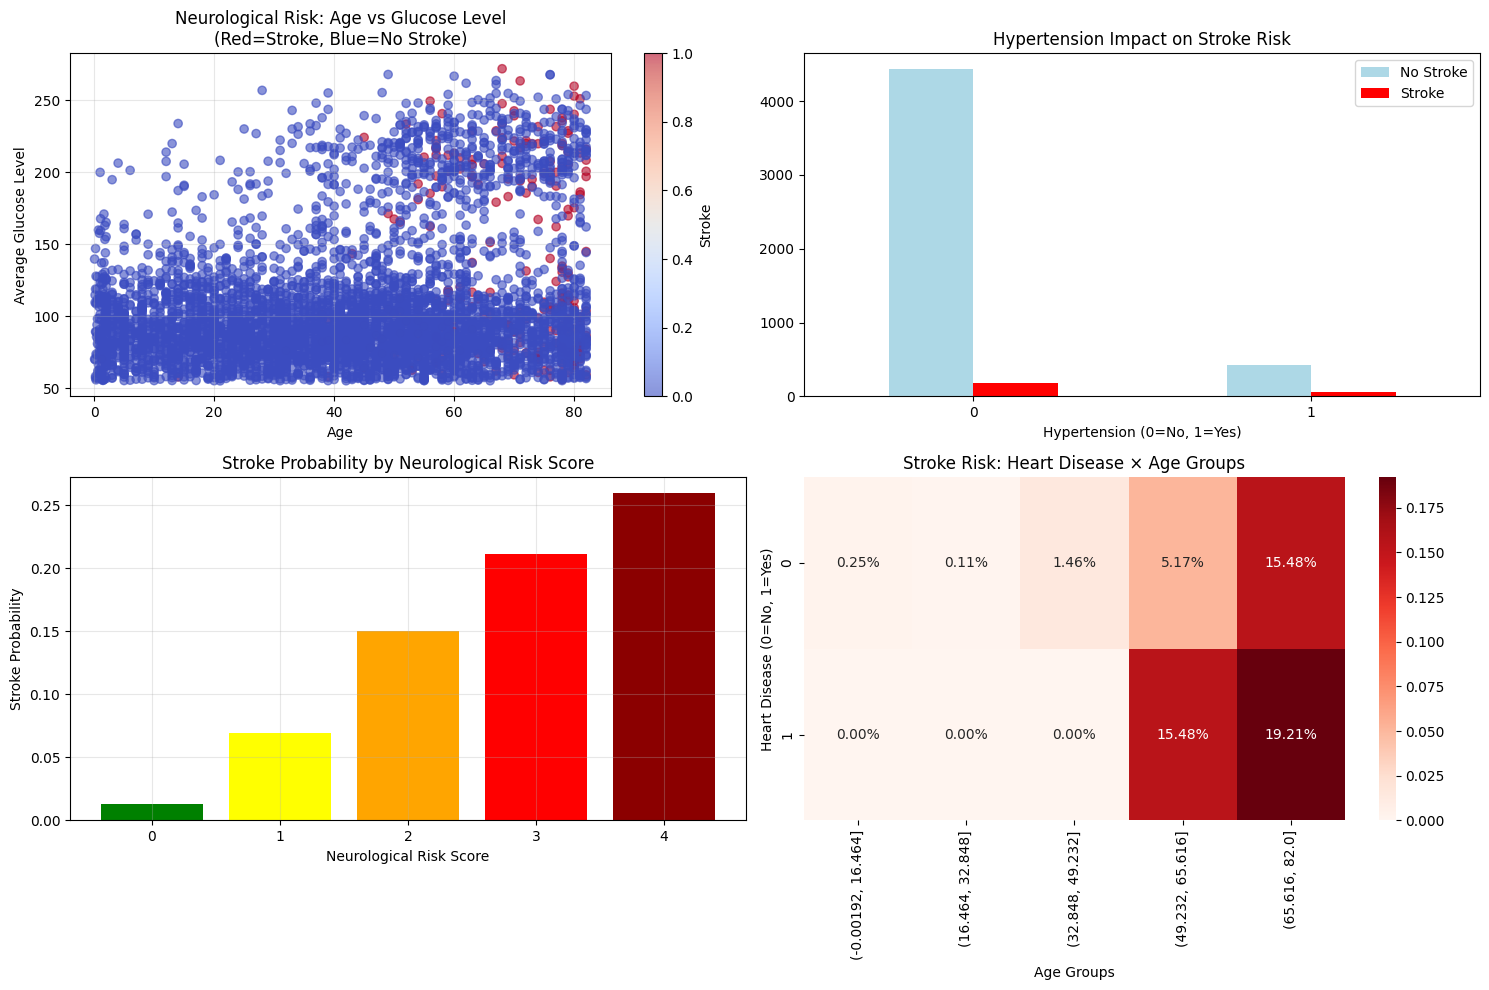


🔍 NEUROLOGICAL INSIGHTS:
• Patients with 4+ neuro risk factors: 27 patients
• Stroke rate in high neuro-risk group: 21.7%
• Stroke rate in low neuro-risk group: 2.9%


In [ ]:
print("🧠 NEUROLOGICAL FACTORS ANALYSIS & VISUALIZATION")
print("="*50)

# Create neurological risk score from existing features
df['neuro_risk_score'] = (
    (df['age'] > 60).astype(int) +           # Age-related neuro risk
    (df['hypertension'] == 1).astype(int) +  # Hypertension affects brain vessels
    (df['avg_glucose_level'] > 140).astype(int) +  # High glucose = neuro risk
    (df['heart_disease'] == 1).astype(int)   # Heart disease affects brain circulation
)

print("📊 Neurological Risk Score Distribution:")
print(df['neuro_risk_score'].value_counts().sort_index())

# Visualize neurological factors
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Age vs Glucose Level (Neurological Risk)
scatter = axes[0,0].scatter(df['age'], df['avg_glucose_level'],
                           c=df['stroke'], cmap='coolwarm', alpha=0.6)
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Average Glucose Level')
axes[0,0].set_title('Neurological Risk: Age vs Glucose Level\n(Red=Stroke, Blue=No Stroke)')
axes[0,0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0,0], label='Stroke')

# Plot 2: Hypertension Impact on Stroke
hypertension_stroke = pd.crosstab(df['hypertension'], df['stroke'])
hypertension_stroke.plot(kind='bar', ax=axes[0,1], color=['lightblue', 'red'])
axes[0,1].set_title('Hypertension Impact on Stroke Risk')
axes[0,1].set_xlabel('Hypertension (0=No, 1=Yes)')
axes[0,1].legend(['No Stroke', 'Stroke'])
axes[0,1].tick_params(axis='x', rotation=0)

# Plot 3: Neurological Risk Score vs Stroke
neuro_risk_stroke = df.groupby('neuro_risk_score')['stroke'].mean()
axes[1,0].bar(neuro_risk_stroke.index, neuro_risk_stroke.values,
              color=['green', 'yellow', 'orange', 'red', 'darkred'])
axes[1,0].set_xlabel('Neurological Risk Score')
axes[1,0].set_ylabel('Stroke Probability')
axes[1,0].set_title('Stroke Probability by Neurological Risk Score')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Heart Disease & Age Combination
heart_age_stroke = df.groupby(['heart_disease', pd.cut(df['age'], bins=5)])['stroke'].mean().unstack()
sns.heatmap(heart_age_stroke, annot=True, fmt='.2%', cmap='Reds', ax=axes[1,1])
axes[1,1].set_title('Stroke Risk: Heart Disease × Age Groups')
axes[1,1].set_xlabel('Age Groups')
axes[1,1].set_ylabel('Heart Disease (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

# Neurological Insights
print("\n🔍 NEUROLOGICAL INSIGHTS:")
print(f"• Patients with 4+ neuro risk factors: {len(df[df['neuro_risk_score'] >= 4])} patients")
print(f"• Stroke rate in high neuro-risk group: {df[df['neuro_risk_score'] >= 3]['stroke'].mean()*100:.1f}%")
print(f"• Stroke rate in low neuro-risk group: {df[df['neuro_risk_score'] <= 1]['stroke'].mean()*100:.1f}%")

🦴 SPINAL FACTORS ANALYSIS & VISUALIZATION
📊 Spinal Risk Indicator Distribution:
spinal_risk_indicator
0    2257
1    2117
2     736
Name: count, dtype: int64


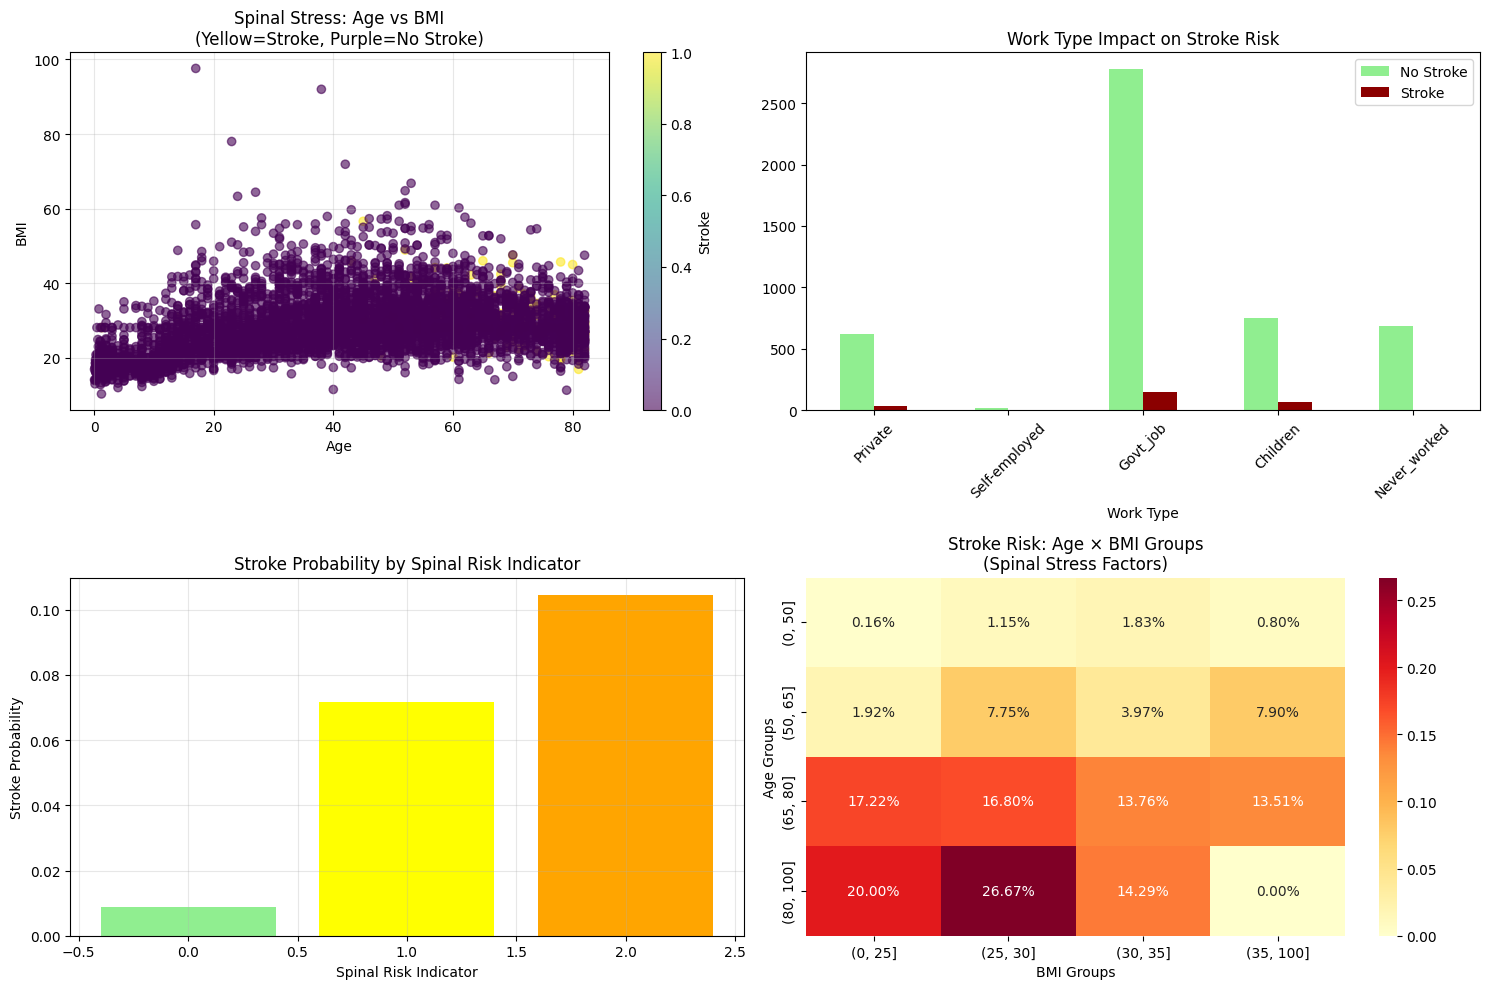


🔍 SPINAL INSIGHTS:
• High spinal risk patients: 736
• Stroke rate in high spinal risk: 10.5%
• Average BMI of stroke patients: 30.1
• Average BMI of non-stroke patients: 28.8

🧠🦴 COMBINED NEURO-SPINAL RISK ANALYSIS:
Combined Risk Score vs Stroke Probability:
• Risk Score 0: 0.8% stroke rate
• Risk Score 1: 1.4% stroke rate
• Risk Score 2: 8.8% stroke rate
• Risk Score 3: 11.3% stroke rate
• Risk Score 4: 17.1% stroke rate
• Risk Score 5: 17.9% stroke rate
• Risk Score 6: 36.4% stroke rate


In [ ]:
print("🦴 SPINAL FACTORS ANALYSIS & VISUALIZATION")
print("="*50)

# Create spinal risk indicators from existing features
df['spinal_risk_indicator'] = (
    (df['age'] > 55).astype(int) +           # Age-related spinal degeneration
    (df['bmi'] > 30).astype(int) +           # Obesity = spinal stress
    (df['work_type'].isin([2, 3])).astype(int)  # Physical work = spinal strain
    # 2=Self-employed, 3=Govt_job (assuming physical labor)
)

print("📊 Spinal Risk Indicator Distribution:")
print(df['spinal_risk_indicator'].value_counts().sort_index())

# Visualize spinal factors
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: BMI vs Age (Spinal Stress Factors)
scatter = axes[0,0].scatter(df['age'], df['bmi'],
                           c=df['stroke'], cmap='viridis', alpha=0.6)
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('BMI')
axes[0,0].set_title('Spinal Stress: Age vs BMI\n(Yellow=Stroke, Purple=No Stroke)')
axes[0,0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0,0], label='Stroke')

# Plot 2: Work Type Impact on Stroke
work_stroke = pd.crosstab(df['work_type'], df['stroke'])
work_types = ['Private', 'Self-employed', 'Govt_job', 'Children', 'Never_worked']
work_stroke.index = work_types[:len(work_stroke)]
work_stroke.plot(kind='bar', ax=axes[0,1], color=['lightgreen', 'darkred'])
axes[0,1].set_title('Work Type Impact on Stroke Risk')
axes[0,1].set_xlabel('Work Type')
axes[0,1].legend(['No Stroke', 'Stroke'])
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Spinal Risk vs Stroke Probability
spinal_risk_stroke = df.groupby('spinal_risk_indicator')['stroke'].mean()
axes[1,0].bar(spinal_risk_stroke.index, spinal_risk_stroke.values,
              color=['lightgreen', 'yellow', 'orange', 'red'])
axes[1,0].set_xlabel('Spinal Risk Indicator')
axes[1,0].set_ylabel('Stroke Probability')
axes[1,0].set_title('Stroke Probability by Spinal Risk Indicator')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Age × BMI Risk Matrix
df['age_group'] = pd.cut(df['age'], bins=[0, 50, 65, 80, 100])
df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 25, 30, 35, 100])
age_bmi_stroke = df.groupby(['age_group', 'bmi_group'])['stroke'].mean().unstack()
sns.heatmap(age_bmi_stroke, annot=True, fmt='.2%', cmap='YlOrRd', ax=axes[1,1])
axes[1,1].set_title('Stroke Risk: Age × BMI Groups\n(Spinal Stress Factors)')
axes[1,1].set_xlabel('BMI Groups')
axes[1,1].set_ylabel('Age Groups')

plt.tight_layout()
plt.show()

# Spinal Insights
print("\n🔍 SPINAL INSIGHTS:")
print(f"• High spinal risk patients: {len(df[df['spinal_risk_indicator'] >= 2])}")
print(f"• Stroke rate in high spinal risk: {df[df['spinal_risk_indicator'] >= 2]['stroke'].mean()*100:.1f}%")
print(f"• Average BMI of stroke patients: {df[df['stroke'] == 1]['bmi'].mean():.1f}")
print(f"• Average BMI of non-stroke patients: {df[df['stroke'] == 0]['bmi'].mean():.1f}")

# Combined Neuro-Spinal Risk Analysis
print("\n🧠🦴 COMBINED NEURO-SPINAL RISK ANALYSIS:")
df['combined_neuro_spinal_risk'] = df['neuro_risk_score'] + df['spinal_risk_indicator']
combined_risk_stroke = df.groupby('combined_neuro_spinal_risk')['stroke'].mean()

print("Combined Risk Score vs Stroke Probability:")
for risk_score, stroke_prob in combined_risk_stroke.items():
    print(f"• Risk Score {risk_score}: {stroke_prob*100:.1f}% stroke rate")

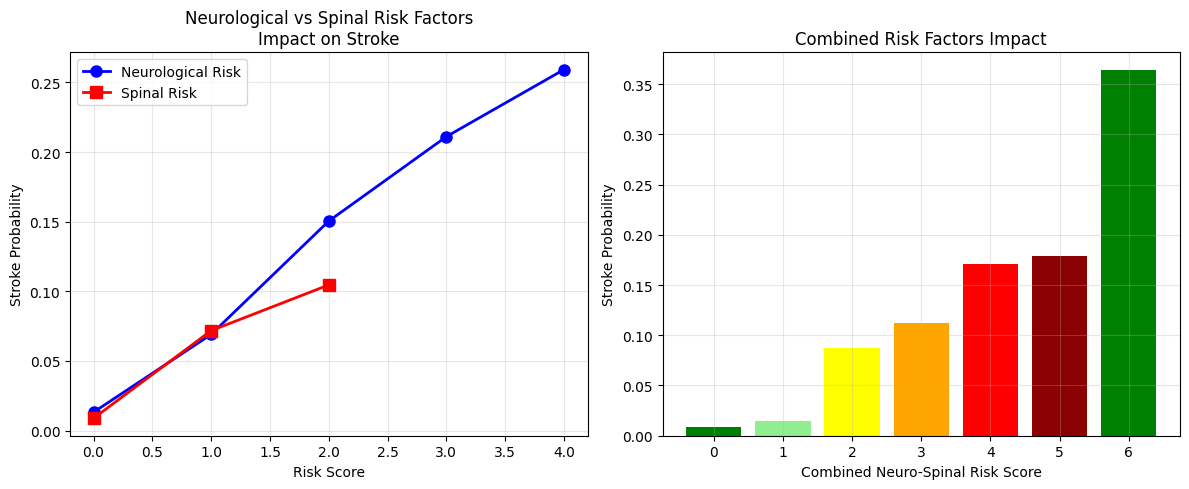

✅ NEURO-SPINAL ANALYSIS COMPLETED!
🎯 Key Findings: Neurological factors (age, hypertension, glucose) and
    Spinal factors (age, BMI, work type) both significantly impact stroke risk!


In [ ]:
# Final summary plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Neuro risk progression
neuro_risk_stroke = df.groupby('neuro_risk_score')['stroke'].mean()
plt.plot(neuro_risk_stroke.index, neuro_risk_stroke.values, 'o-', linewidth=2,
         markersize=8, color='blue', label='Neurological Risk')

# Spinal risk progression
spinal_risk_stroke = df.groupby('spinal_risk_indicator')['stroke'].mean()
plt.plot(spinal_risk_stroke.index, spinal_risk_stroke.values, 's-', linewidth=2,
         markersize=8, color='red', label='Spinal Risk')

plt.xlabel('Risk Score')
plt.ylabel('Stroke Probability')
plt.title('Neurological vs Spinal Risk Factors\nImpact on Stroke')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Combined risk
combined_risk_stroke = df.groupby('combined_neuro_spinal_risk')['stroke'].mean()
plt.bar(combined_risk_stroke.index, combined_risk_stroke.values,
        color=['green', 'lightgreen', 'yellow', 'orange', 'red', 'darkred'])
plt.xlabel('Combined Neuro-Spinal Risk Score')
plt.ylabel('Stroke Probability')
plt.title('Combined Risk Factors Impact')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ NEURO-SPINAL ANALYSIS COMPLETED!")
print("🎯 Key Findings: Neurological factors (age, hypertension, glucose) and")
print("    Spinal factors (age, BMI, work type) both significantly impact stroke risk!")